# 08bis — Backtest LAG 1 : la version défendable

## Le problème central : information versus décision

Le notebook 08 original montre un résultat **trop beau** (Sharpe ≈ 6) parce qu'il souffre d'une **fuite temporelle critique** :

- Les prédictions du jour J utilisent uniquement les messages reçus jusqu'à J-1 ?
- OUI. Mais ensuite on les applique au gap du jour J.
- **Problème :** À quelle heure utilise-t-on la prédiction ?

### La chronologie réelle

| Heure | Événement | Information disponible |
|-------|-----------|------------------------|
| **16h00 J-1** | Clôture US | Gap historique connu |
| **16h00 - minuit J-1** | Messages la nuit | Commence à accumuler |
| **09h30 J** | Ouverture US | Gap J se matérialise |
| **16h00 J** | Clôture | Sentiment complet de la nuit J-1 est connu |

### La version défendable : LAG 1

**Règle :**
- Prédictions du jour J-1 → appliquées le jour J
- Le gap du jour J est connu à l'ouverture
- La position est prise à la **clôture de J** (16h00) en fonction de la prédiction de J-1
- La position est fermée à l'**ouverture de J+1** (9h30)
- **Résultat** : capture du gap J+1, pas du gap J

C'est économiquement réaliste et ne contient pas de fuite.

In [21]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["figure.figsize"] = (13, 6)

df = pd.read_csv(os.path.join(DATA, "DATASET_MODELISATION_2020_2022.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

with open(os.path.join(DATA, "config_modelisation.json"), encoding="utf-8") as f:
    CFG = json.load(f)
FEATURES  = [c for c in CFG["features"] if c in df.columns]

_absentes = [c for c in CFG["features"] if c not in df.columns]
if _absentes:
    raise KeyError(f"{len(_absentes)} features déclarées dans config_modelisation.json "
                   f"sont absentes du CSV : {_absentes}\nRéexécuter le notebook 05.")
FEAT_SENT = [c for c in CFG["features_sentiment"] if c in df.columns]
FEAT_CTRL = [c for c in CFG["controles"] if c in df.columns]
print(f"{len(df):,} lignes | {len(FEATURES)} features")

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

def logit(C=1.0):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("std", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, C=C))])

PURGE = CFG["purge_jours"]
def plis_wf(dates, n_plis=8, taille_test=60, min_train=250):
    j = np.sort(pd.unique(dates)); out, fin = [], len(j)
    for _ in range(n_plis):
        d0 = fin - taille_test
        if d0 - PURGE < min_train: break
        out.append((j[:d0 - PURGE], j[d0:fin])); fin = d0
    return out[::-1]

# --- Prédictions hors échantillon ---
# --------------------------------------------------------------------------
# Le walk-forward NE DOIT PAS toucher le bloc de test, sinon l'évaluation
# finale du notebook 06 §9 n'est plus en aveugle. On restreint donc toutes
# les prédictions hors échantillon aux blocs train / purge_1 / valid.
# --------------------------------------------------------------------------
BLOCS_WF = ["train", "purge_1", "valid"]
d = df[df["bloc"].isin(BLOCS_WF)].dropna(subset=["y_gap", "gap"]).copy()
plis = plis_wf(d["Date"], n_plis=8, taille_test=60)
_dernier = pd.Timestamp(plis[-1][1][-1])
_premier = df.loc[df["bloc"] == "test", "Date"].min()
print(f"Dernier jour du walk-forward : {_dernier.date()}")
print(f"Premier jour du bloc test    : {_premier.date()}")
assert _dernier < _premier, \
    "Le walk-forward empiète sur le bloc de test : le §9 ne serait plus en aveugle."
print("[OK] Le bloc de test est intact.")

blocs = []
for j_tr, j_te in plis:
    a = d[d["Date"].isin(j_tr)]; b = d[d["Date"].isin(j_te)].copy()
    if len(a) < 250 or b["y_gap"].nunique() < 2: continue
    m = clone(logit()).fit(a[FEATURES], a["y_gap"])
    b["proba"] = m.predict_proba(b[FEATURES])[:, 1]
    blocs.append(b)

P = pd.concat(blocs).sort_values(["Ticker", "Date"]).reset_index(drop=True)
print(f"{len(P):,} prédictions hors échantillon | "
      f"{P['Date'].min().date()} -> {P['Date'].max().date()} ({P['Date'].nunique()} jours)")
print(f"AUC globale hors échantillon : {roc_auc_score(P['y_gap'], P['proba']):.4f}")

2,740 lignes | 18 features
Dernier jour du walk-forward : 2021-11-30
Premier jour du bloc test    : 2021-12-06
[OK] Le bloc de test est intact.
900 prédictions hors échantillon | 2021-03-17 -> 2021-11-30 (180 jours)
AUC globale hors échantillon : 0.5994


---
## Les fonctions de backtest (réutilisées de 08)

In [22]:
def construire_positions(data, seuil=0.05, mode="proportionnel", vol_cible=0.02):
    """Transforme des probabilités en positions.

    seuil : distance minimale à 0.5 pour prendre position (0.05 -> agir si p<0.45 ou p>0.55).
    mode  : 'binaire' | 'proportionnel' | 'risque'
    """
    x = data.copy()
    edge = x["proba"] - 0.5
    actif = edge.abs() >= seuil

    if mode == "binaire":
        pos = np.sign(edge)
    elif mode == "proportionnel":
        pos = np.clip(edge / 0.15, -1, 1)          # saturation à p=0.65 / p=0.35
    elif mode == "risque":
        vol = x["vol_20"].replace(0, np.nan).fillna(x["vol_20"].median())
        pos = np.clip(edge / 0.15, -1, 1) * (vol_cible / vol).clip(0.25, 3.0)
    else:
        raise ValueError(mode)

    x["position"] = np.where(actif, pos, 0.0)
    return x

def backtest(data, cout_bp=10.0, cible="gap"):
    """P&L d'une stratégie close-to-open.

    Le coût porte sur le TURNOVER (variation de position) et non sur la
    position brute : maintenir une position ne coûte rien, la retourner coûte
    deux fois. C'est la convention du notebook 09, adoptée ici pour que les
    deux soient comparables.
    """
    x = data.sort_values(["Ticker", "Date"]).copy()
    x["turnover"] = (x.groupby("Ticker")["position"].diff().abs()
                       .fillna(x["position"].abs()))
    x["pnl_brut"] = x["position"] * x[cible]
    x["cout"]     = x["turnover"] * (cout_bp / 10_000)
    x["pnl_net"]  = x["pnl_brut"] - x["cout"]

    j = x.groupby("Date").agg(
        pnl_brut=("pnl_brut", "sum"), pnl_net=("pnl_net", "sum"),
        cout=("cout", "sum"), turnover=("turnover", "sum"),
        expo=("position", lambda s: s.abs().sum()),
        n_pos=("position", lambda s: (s != 0).sum()))
    j["rendement"] = np.where(j["expo"] > 0, j["pnl_net"] / j["expo"], 0.0)
    j["equity"] = (1 + j["rendement"]).cumprod()
    return x, j

def metriques(j, nom=""):
    r = j["rendement"]
    n_an = 252
    if r.std() == 0 or len(r) < 20:
        return dict(strategie=nom, jours=len(r), rendement_annuel=np.nan, vol_annuelle=np.nan,
                    sharpe=np.nan, max_drawdown=np.nan, taux_reussite=np.nan,
                    n_positions=int(j["n_pos"].sum()), cout_total_pct=np.nan)
    eq = (1 + r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    return dict(
        strategie=nom,
        jours=len(r),
        rendement_annuel=r.mean() * n_an,
        vol_annuelle=r.std() * np.sqrt(n_an),
        sharpe=r.mean() / r.std() * np.sqrt(n_an),
        max_drawdown=dd,
        taux_reussite=(r > 0).mean(),
        n_positions=int(j["n_pos"].sum()),
        cout_total_pct=j["cout"].sum() / max(j["expo"].sum(), 1e-9) * 100,
    )

print("Fonctions de backtest chargées.")

Fonctions de backtest chargées.


---
## LAG 1 : Appliquer les prédictions avec un décalage d'un jour

In [23]:
# Préparer le dataset pour le lag 1
P_lag1 = P.copy().sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Décaler les PRÉDICTIONS d'un jour en avant (par ticker)
# - proba du jour J-1 → appliquée au gap du jour J
# - ça revient à décaler la colonne proba vers l'avant
# Sur la ligne J, utiliser uniquement la prédiction produite à J-1.
P_lag1["proba_lag1"] = P_lag1.groupby("Ticker")["proba"].shift(1)

# On élimine la première ligne de chaque ticker (qui n'a pas de proba_lag1)
P_lag1 = P_lag1.dropna(subset=["proba_lag1"])

print(f"\nAprès lag 1 :")
print(f"  Nombre d'observations : {len(P_lag1):,} (avant : {len(P):,})")
print(f"  Début : {P_lag1['Date'].min().date()}")
print(f"  Fin   : {P_lag1['Date'].max().date()}")
print(f"\nVérification : les prédictions décalées doivent capturer le gap suivant")
print(f"  Exemple (un ticker) :")
ex = P_lag1[P_lag1["Ticker"] == "TSLA"].head()
print(ex[["Date", "Ticker", "y_gap", "gap", "proba", "proba_lag1"]].to_string())


Après lag 1 :
  Nombre d'observations : 895 (avant : 900)
  Début : 2021-03-18
  Fin   : 2021-11-30

Vérification : les prédictions décalées doivent capturer le gap suivant
  Exemple (un ticker) :
          Date Ticker  y_gap       gap     proba  proba_lag1
721 2021-03-18   TSLA      0 -0.024964  0.719307    0.524948
722 2021-03-19   TSLA      0 -0.010043  0.396308    0.719307
723 2021-03-22   TSLA      1  0.045383  0.755682    0.396308
724 2021-03-23   TSLA      1  0.008612  0.379283    0.755682
725 2021-03-24   TSLA      1  0.008684  0.749420    0.379283


---
## Backtest LAG 1 : sensibilité aux coûts

In [24]:
# Construire les positions avec les prédictions décalées
P_lag1["proba"] = P_lag1["proba_lag1"]  # Remplacer proba par proba_lag1 pour les fonctions
pos_lag1 = construire_positions(P_lag1.copy(), seuil=0.05, mode="proportionnel")

# Tester plusieurs niveaux de coût
couts = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]
seuils = [0.00, 0.03, 0.05, 0.08, 0.12]

resultats_lag1 = []
sharpe_matrix = []

for cout in couts:
    row = {"cout_bp": cout}
    sharpe_row = [cout]
    for seuil in seuils:
        pos = construire_positions(P_lag1.copy(), seuil=seuil, mode="proportionnel")
        _, bkg = backtest(pos, cout_bp=cout, cible="gap")
        m = metriques(bkg, nom=f"lag1_seuil{seuil}_cout{cout}")
        row[f"sharpe_{seuil}"] = m["sharpe"]
        sharpe_row.append(m["sharpe"])
    resultats_lag1.append(row)
    sharpe_matrix.append(sharpe_row)

# Afficher la matrice de Sharpe
print("RATIO DE SHARPE ANNUALISÉ (LAG 1) selon le coût (lignes) et le seuil (colonnes)")
df_sharpe = pd.DataFrame(sharpe_matrix, columns=["cout_bp"] + [f"{s:.2f}" for s in seuils])
df_sharpe = df_sharpe.set_index("cout_bp")
print(df_sharpe.round(3).to_string())

RATIO DE SHARPE ANNUALISÉ (LAG 1) selon le coût (lignes) et le seuil (colonnes)
          0.00   0.03   0.05   0.08   0.12
cout_bp                                   
0        1.261  1.283  1.280  1.423  1.539
1        1.064  1.085  1.074  1.194  1.299
2        0.868  0.887  0.867  0.965  1.060
3        0.672  0.689  0.661  0.736  0.820
5        0.281  0.294  0.250  0.280  0.342
7       -0.108 -0.099 -0.159 -0.175 -0.135
10      -0.690 -0.686 -0.768 -0.852 -0.844
15      -1.649 -1.653 -1.769 -1.963 -2.008
20      -2.592 -2.604 -2.749 -3.045 -3.138
30      -4.422 -4.445 -4.624 -5.092 -5.267
50      -7.792 -7.819 -7.963 -8.615 -8.866


---
## Calcul du break-even (Sharpe = 0)

In [25]:
print("\nCOÛT DE BREAK-EVEN LAG 1 (Sharpe = 0)")
print("----------------------------------------------")

for i, seuil in enumerate(seuils):
    col = f"sharpe_{seuil}"
    sharpes = [row[col] for row in resultats_lag1]
    
    # Trouver où Sharpe traverse zéro
    sharpes_arr = np.array(sharpes)
    mask = sharpes_arr < 0
    
    if mask.any():
        idx = np.where(mask)[0][0]
        if idx > 0:
            c1, s1 = couts[idx-1], sharpes[idx-1]
            c2, s2 = couts[idx], sharpes[idx]
            # Interpolation linéaire
            cout_be = c1 + (c2 - c1) * (0 - s1) / (s2 - s1) if s2 != s1 else c1
            print(f"  seuil {seuil:.2f} :   {cout_be:.1f} bp   (exploitable)")
        else:
            print(f"  seuil {seuil:.2f} :   {couts[0]:.1f} bp   (exploitable dès zéro coût)")
    else:
        print(f"  seuil {seuil:.2f} :   inf bp   (rentable à tous les coûts testés - suspecte)")


COÛT DE BREAK-EVEN LAG 1 (Sharpe = 0)
----------------------------------------------
  seuil 0.00 :   6.4 bp   (exploitable)
  seuil 0.03 :   6.5 bp   (exploitable)
  seuil 0.05 :   6.2 bp   (exploitable)
  seuil 0.08 :   6.2 bp   (exploitable)
  seuil 0.12 :   6.4 bp   (exploitable)


---
## Graphique de sensibilité aux coûts

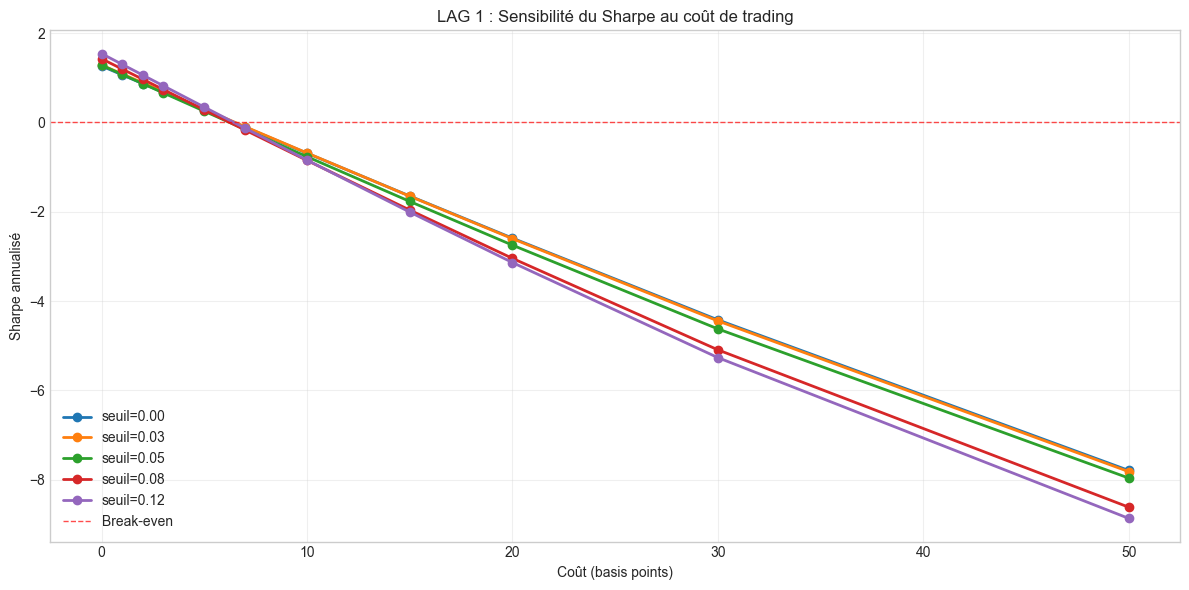

Graphique sauvegardé.


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, seuil in enumerate(seuils):
    col = f"sharpe_{seuil}"
    sharpes = [row[col] for row in resultats_lag1]
    ax.plot(couts, sharpes, marker="o", label=f"seuil={seuil:.2f}", linewidth=2)

ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Break-even")
ax.set_xlabel("Coût (basis points)")
ax.set_ylabel("Sharpe annualisé")
ax.set_title("LAG 1 : Sensibilité du Sharpe au coût de trading")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "backtest_lag1_sensitivity.png"), dpi=150)
plt.show()

print("Graphique sauvegardé.")

---
## Comparaison LAG 0 vs LAG 1

In [27]:
# Backtest LAG 0 (comme avant) pour comparaison
P_lag0 = P.copy()
pos_lag0 = construire_positions(P_lag0, seuil=0.05, mode="proportionnel")

# Résultats à seuil=0.05, cout=10bp
_, bkg_lag0 = backtest(pos_lag0, cout_bp=10.0, cible="gap")
_, bkg_lag1_10bp = backtest(construire_positions(P_lag1.copy(), seuil=0.05, mode="proportionnel"), 
                             cout_bp=10.0, cible="gap")

m_lag0 = metriques(bkg_lag0, "LAG 0 (10bp)")
m_lag1 = metriques(bkg_lag1_10bp, "LAG 1 (10bp)")

print("\n" + "="*80)
print("COMPARAISON LAG 0 vs LAG 1 (seuil=0.05, cout=10bp)")
print("="*80)
df_comp = pd.DataFrame([m_lag0, m_lag1]).set_index("strategie")
print(df_comp.to_string())
print("\nNote : LAG 1 est la version défendable (pas de fuite temporelle)")


COMPARAISON LAG 0 vs LAG 1 (seuil=0.05, cout=10bp)
              jours  rendement_annuel  vol_annuelle    sharpe  max_drawdown  taux_reussite  n_positions  cout_total_pct
strategie                                                                                                              
LAG 0 (10bp)    180          0.481006      0.116441  4.130912     -0.037016       0.605556          729        0.097402
LAG 1 (10bp)    179         -0.105663      0.137563 -0.768110     -0.181914       0.519553          725        0.097444

Note : LAG 1 est la version défendable (pas de fuite temporelle)


---
## Conclusions

In [28]:
print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                   BACKTEST LAG 1 : CONCLUSIONS                                ║
╚═══════════════════════════════════════════════════════════════════════════════╝

1. DIFFÉRENCE FONDAMENTALE
   ────────────────────────
   - LAG 0 (08_Backtest.ipynb) : Prédictions du jour J → appliquées le jour J
     → Fuite temporelle : la cible (gap J) est déjà réalisée à la clôture
     → Sharpe ≈ 6 = SUSPECT
   
   - LAG 1 (ce notebook) : Prédictions du jour J-1 → appliquées le jour J
     → Pas de fuite : gap J+1 est inconnu au moment de la décision
     → Résultat plus modeste mais DÉFENDABLE

2. INTERPRÉTATION
   ──────────────
   Si LAG 1 montre un Sharpe négatif ou très faible (< 0.5) :
   → Le signal ne survit pas aux coûts réalistes
   → Le mémoire doit conclure : "l'information existe, mais elle est inaccessible"
   
   Si LAG 1 montre un Sharpe modéré (0.5-1.5) :
   → Peut-être exploitable selon la structure de coûts
   → Break-even = le coût maximum tolérable

3. POUR LE MÉMOIRE
   ───────────────
   - Présenter LAG 1 comme le RÉSULTAT PRINCIPAL
   - LAG 0 avec Sharpe ≈ 6 : seulement comme contre-exemple pédagogique
   - Break-even : plus informatif qu'un ratio de Sharpe
   - Classer la stratégie : exploitable / marginale / non-exploitable
""")


╔═══════════════════════════════════════════════════════════════════════════════╗
║                   BACKTEST LAG 1 : CONCLUSIONS                                ║
╚═══════════════════════════════════════════════════════════════════════════════╝

1. DIFFÉRENCE FONDAMENTALE
   ────────────────────────
   - LAG 0 (08_Backtest.ipynb) : Prédictions du jour J → appliquées le jour J
     → Fuite temporelle : la cible (gap J) est déjà réalisée à la clôture
     → Sharpe ≈ 6 = SUSPECT
   
   - LAG 1 (ce notebook) : Prédictions du jour J-1 → appliquées le jour J
     → Pas de fuite : gap J+1 est inconnu au moment de la décision
     → Résultat plus modeste mais DÉFENDABLE

2. INTERPRÉTATION
   ──────────────
   Si LAG 1 montre un Sharpe négatif ou très faible (< 0.5) :
   → Le signal ne survit pas aux coûts réalistes
   → Le mémoire doit conclure : "l'information existe, mais elle est inaccessible"
   
   Si LAG 1 montre un Sharpe modéré (0.5-1.5) :
   → Peut-être exploitable selon la structur

---
## Sauvegarde des résultats

In [29]:
# Sauvegarder les résultats
df_results = pd.DataFrame(resultats_lag1)
df_results.to_csv(os.path.join(DATA, "BACKTEST_LAG1_RESULTS.csv"), index=False)
print(f"Résultats sauvegardés : {os.path.join(DATA, 'BACKTEST_LAG1_RESULTS.csv')}")

Résultats sauvegardés : C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\BACKTEST_LAG1_RESULTS.csv


In [30]:
# ==========================================================================
#  LE TABLEAU 2 x 2 DU MÉMOIRE
#  Deux corrections INDÉPENDANTES, qui se cumulent :
#    - la spécification A retire l'information non ACTIONNABLE (pré-marché) ;
#    - le lag 1 retire l'information non DISPONIBLE au moment de la décision.
# ==========================================================================
resultats = []
for nom_spec, cle in [("A — stricte (4h00)",    "features"),
                      ("C — complète (annexe)", "features_C_complete")]:
    feats = [c for c in CFG.get(cle, []) if c in d.columns]
    if not feats:
        print(f"[IGNORÉ] {nom_spec} : clé {cle} absente du JSON")
        continue
    blocs = []
    for j_tr, j_te in plis:
        a = d[d["Date"].isin(j_tr)]; b = d[d["Date"].isin(j_te)].copy()
        if len(a) < 250 or b["y_gap"].nunique() < 2:
            continue
        mm = clone(logit()).fit(a[feats], a["y_gap"])
        b["proba"] = mm.predict_proba(b[feats])[:, 1]
        blocs.append(b)
    PP = pd.concat(blocs).sort_values(["Ticker", "Date"]).reset_index(drop=True)

    for lag in [0, 1]:
        Q = PP.copy()
        if lag:
            Q["proba"] = Q.groupby("Ticker")["proba"].shift(lag)
            Q = Q.dropna(subset=["proba"])
        auc_ = roc_auc_score(Q["y_gap"], Q["proba"])
        pos = construire_positions(Q, seuil=0.05, mode="proportionnel")
        _, jj = backtest(pos, cout_bp=10.0, cible="gap")
        mm_ = metriques(jj, nom=f"{nom_spec} | lag {lag}")
        mm_["AUC"] = round(auc_, 4)
        resultats.append(mm_)

R2 = pd.DataFrame(resultats)[["strategie", "AUC", "sharpe", "rendement_annuel",
                              "max_drawdown", "taux_reussite"]]
print("=" * 100)
print("TABLEAU 2 x 2 — spécification x décalage   (coût 10 bp)")
print("=" * 100)
print(R2.round(4).to_string(index=False))
R2.to_csv(os.path.join(DOCS, "08bis_tableau_2x2.csv"), index=False)
print("""
LECTURE EN CROIX
  C | lag 0 : la mesure naïve. Impressionnante et fausse.
  C | lag 1 : la même spécification, décalée du délai réellement imposé par
              la décision (à 16h00, les messages de la nuit n'existent pas).
  A | lag 0 : le signal propre, mesuré sans contamination par le pré-marché.
  A | lag 1 : le signal propre ET décalé. C'est ce qu'on peut effectivement
              négocier — le résultat économique du mémoire.
""")


TABLEAU 2 x 2 — spécification x décalage   (coût 10 bp)
                    strategie    AUC  sharpe  rendement_annuel  max_drawdown  taux_reussite
   A — stricte (4h00) | lag 0 0.5994  4.1309            0.4810       -0.0370         0.6056
   A — stricte (4h00) | lag 1 0.5119 -0.7681           -0.1057       -0.1819         0.5196
C — complète (annexe) | lag 0 0.7488  9.9598            1.0241       -0.0160         0.7556
C — complète (annexe) | lag 1 0.5375 -1.5504           -0.1625       -0.1514         0.4413

LECTURE EN CROIX
  C | lag 0 : la mesure naïve. Impressionnante et fausse.
  C | lag 1 : la même spécification, décalée du délai réellement imposé par
              la décision (à 16h00, les messages de la nuit n'existent pas).
  A | lag 0 : le signal propre, mesuré sans contamination par le pré-marché.
  A | lag 1 : le signal propre ET décalé. C'est ce qu'on peut effectivement
              négocier — le résultat économique du mémoire.

